In [1]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
path = str(Path.cwd().parent)
print(path)
sys.path.insert(1, path)

import numpy as np
import pandas as pd
import skforecast

print(skforecast.__version__)

/Users/javier.escobar/code/github/skforecast
0.24.0


In [2]:
# ==============================================================================
# `dropna_from_series=True`: ForecasterDirectMultiVariate vs ForecasterRecursiveMultiSeries
# ==============================================================================
import warnings
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression, Ridge
from skforecast.direct import ForecasterDirectMultiVariate
from skforecast.recursive import ForecasterRecursiveMultiSeries
from skforecast.model_selection import backtesting_forecaster_multiseries, TimeSeriesFold

# warnings.filterwarnings("ignore")

# Data: 3 series, a single NaN in `l2` that falls inside the last window of a fold
# ==============================================================================
rng = np.random.default_rng(123)
n = 120
series = pd.DataFrame(
    {f"l{i}": rng.normal(10 * i, 1, n) for i in (1, 2, 3)},
    index=pd.date_range("2020-01-01", periods=n, freq="D"),
).asfreq("D")
series.iloc[78, series.columns.get_loc("l2")] = np.nan

cv = TimeSeriesFold(steps=5, initial_train_size=60, refit=False)


def backtest(forecaster, label):
    print(f"\n--- {label}")
    try:
        metric, preds = backtesting_forecaster_multiseries(
            forecaster=forecaster, series=series, cv=cv,
            metric="mean_absolute_error",
            verbose=False, show_progress=False, suppress_warnings=False,
        )
        print(f"OK  | {len(preds)} predictions | levels: {sorted(preds['level'].unique())}")
        return metric, preds
    except ValueError as e:
        print(f"ValueError: {str(e).splitlines()[0]}")


# ForecasterDirectMultiVariate: every series is a predictor of the single `level`
# ==============================================================================
_ = backtest(
    ForecasterDirectMultiVariate(
        estimator=LinearRegression(), level="l1", lags=5, steps=5,
        dropna_from_series=False),
    "DirectMultiVariate + LinearRegression (no native NaN support)",
)
_ = backtest(
    ForecasterDirectMultiVariate(
        estimator=LinearRegression(), level="l1", lags=5, steps=5,
        dropna_from_series=True),
    "DirectMultiVariate + LinearRegression (no native NaN support)",
)
_ = backtest(
    ForecasterDirectMultiVariate(
        estimator=LGBMRegressor(random_state=123, verbose=-1), level="l1", lags=5, steps=5,
        dropna_from_series=False),
    "DirectMultiVariate + False + LGBMRegressor (native NaN support)",
)
_ = backtest(
    ForecasterDirectMultiVariate(
        estimator=LGBMRegressor(random_state=123, verbose=-1), level="l1", lags=5, steps=5,
        dropna_from_series=True),
    "DirectMultiVariate + True + LGBMRegressor (native NaN support)",
)

# ForecasterRecursiveMultiSeries: the level is simply skipped in the affected fold
# ==============================================================================
_ = backtest(
    ForecasterRecursiveMultiSeries(
        estimator=LinearRegression(), lags=5, dropna_from_series=True),
    "RecursiveMultiSeries + LinearRegression (no native NaN support)",
)
_ = backtest(
    ForecasterRecursiveMultiSeries(
        estimator=LGBMRegressor(random_state=123, verbose=-1), lags=5,
        dropna_from_series=True),
    "RecursiveMultiSeries + LGBMRegressor (native NaN support)",
)


--- DirectMultiVariate + LinearRegression (no native NaN support)


╭──────────────────────────────── MissingValuesWarning ────────────────────────────────╮
│ `last_window` has missing values. Most of machine learning models do not allow       │
│ missing values. Prediction method may either raise an error or return NaN            │
│ predictions.                                                                         │
│                                                                                      │
│ Category : skforecast.exceptions.MissingValuesWarning                                │
│ Location :                                                                           │
│ /Users/javier.escobar/code/github/skforecast/skforecast/utils/utils.py:1393          │
│ Suppress : warnings.simplefilter('ignore', category=MissingValuesWarning)            │
╰──────────────────────────────────────────────────────────────────────────────────────╯

OK  | 60 predictions | levels: ['l1']

--- DirectMultiVariate + LinearRegression (no native NaN support)


╭──────────────────────────────── MissingValuesWarning ────────────────────────────────╮
│ `last_window` has missing values. Most of machine learning models do not allow       │
│ missing values. Prediction method may either raise an error or return NaN            │
│ predictions.                                                                         │
│                                                                                      │
│ Category : skforecast.exceptions.MissingValuesWarning                                │
│ Location :                                                                           │
│ /Users/javier.escobar/code/github/skforecast/skforecast/utils/utils.py:1393          │
│ Suppress : warnings.simplefilter('ignore', category=MissingValuesWarning)            │
╰──────────────────────────────────────────────────────────────────────────────────────╯

OK  | 60 predictions | levels: ['l1']

--- DirectMultiVariate + False + LGBMRegressor (native NaN support)


╭──────────────────────────────── MissingValuesWarning ────────────────────────────────╮
│ `last_window` has missing values. Most of machine learning models do not allow       │
│ missing values. Prediction method may either raise an error or return NaN            │
│ predictions.                                                                         │
│                                                                                      │
│ Category : skforecast.exceptions.MissingValuesWarning                                │
│ Location :                                                                           │
│ /Users/javier.escobar/code/github/skforecast/skforecast/utils/utils.py:1393          │
│ Suppress : warnings.simplefilter('ignore', category=MissingValuesWarning)            │
╰──────────────────────────────────────────────────────────────────────────────────────╯

OK  | 60 predictions | levels: ['l1']

--- DirectMultiVariate + True + LGBMRegressor (native NaN support)


╭──────────────────────────────── MissingValuesWarning ────────────────────────────────╮
│ `last_window` has missing values. Most of machine learning models do not allow       │
│ missing values. Prediction method may either raise an error or return NaN            │
│ predictions.                                                                         │
│                                                                                      │
│ Category : skforecast.exceptions.MissingValuesWarning                                │
│ Location :                                                                           │
│ /Users/javier.escobar/code/github/skforecast/skforecast/utils/utils.py:1393          │
│ Suppress : warnings.simplefilter('ignore', category=MissingValuesWarning)            │
╰──────────────────────────────────────────────────────────────────────────────────────╯

OK  | 60 predictions | levels: ['l1']


╭───────────────────────────── DataTransformationWarning ──────────────────────────────╮
│ When using a linear model, it is recommended to use a transformer_series to ensure   │
│ all series are in the same scale. You can use, for example, a `StandardScaler` from  │
│ sklearn.preprocessing.                                                               │
│                                                                                      │
│ Category : skforecast.exceptions.DataTransformationWarning                           │
│ Location :                                                                           │
│ /Users/javier.escobar/code/github/skforecast/skforecast/recursive/_forecaster_recurs │
│ ive_multiseries.py:533                                                               │
│ Suppress : warnings.simplefilter('ignore', category=DataTransformationWarning)       │
╰──────────────────────────────────────────────────────────────────────────────────────╯


--- RecursiveMultiSeries + LinearRegression (no native NaN support)


╭────────────────────────────────── InputTypeWarning ──────────────────────────────────╮
│ Passing a DataFrame (either wide or long format) as `series` requires additional     │
│ internal transformations, which can increase computational time. It is recommended   │
│ to use a dictionary of pandas Series instead. For more details, see:                 │
│ https://skforecast.org/latest/user_guides/independent-multi-time-series-forecasting. │
│ html#input-data                                                                      │
│                                                                                      │
│ Category : skforecast.exceptions.InputTypeWarning                                    │
│ Location :                                                                           │
│ /Users/javier.escobar/code/github/skforecast/skforecast/utils/utils.py:3444          │
│ Suppress : warnings.simplefilter('ignore', category=InputTypeWarning)                │
╰──────────────────────────────────────────────────────────────────────────────────────╯

OK  | 175 predictions | levels: ['l1', 'l2', 'l3']

--- RecursiveMultiSeries + LGBMRegressor (native NaN support)


╭────────────────────────────────── InputTypeWarning ──────────────────────────────────╮
│ Passing a DataFrame (either wide or long format) as `series` requires additional     │
│ internal transformations, which can increase computational time. It is recommended   │
│ to use a dictionary of pandas Series instead. For more details, see:                 │
│ https://skforecast.org/latest/user_guides/independent-multi-time-series-forecasting. │
│ html#input-data                                                                      │
│                                                                                      │
│ Category : skforecast.exceptions.InputTypeWarning                                    │
│ Location :                                                                           │
│ /Users/javier.escobar/code/github/skforecast/skforecast/utils/utils.py:3444          │
│ Suppress : warnings.simplefilter('ignore', category=InputTypeWarning)                │
╰──────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────── MissingValuesWarning ────────────────────────────────╮
│ `last_window` has missing values. Most of machine learning models do not allow       │
│ missing values. Prediction method may either raise an error or return NaN            │
│ predictions.                                                                         │
│                                                                                      │
│ Category : skforecast.exceptions.MissingValuesWarning                                │
│ Location :                                                                           │
│ /Users/javier.escobar/code/github/skforecast/skforecast/utils/utils.py:1393          │
│ Suppress : warnings.simplefilter('ignore', category=MissingValuesWarning)            │
╰──────────────────────────────────────────────────────────────────────────────────────╯

OK  | 180 predictions | levels: ['l1', 'l2', 'l3']


In [3]:
from sklearn.svm import SVR

cv = TimeSeriesFold(
    steps=5, initial_train_size=60, refit=False
)

metric_1, preds_1 = backtest(
    ForecasterDirectMultiVariate(
        estimator=LinearRegression(), level="l1", lags=5, steps=5,
        dropna_from_series=False),
    "DirectMultiVariate + LinearRegression (no native NaN support)",
)
metric_2, preds_2 = backtest(
    ForecasterDirectMultiVariate(
        estimator=LinearRegression(), level="l1", lags=5, steps=5,
        dropna_from_series=True),
    "DirectMultiVariate + LinearRegression (no native NaN support)",
)


--- DirectMultiVariate + LinearRegression (no native NaN support)


╭──────────────────────────────── MissingValuesWarning ────────────────────────────────╮
│ `last_window` has missing values. Most of machine learning models do not allow       │
│ missing values. Prediction method may either raise an error or return NaN            │
│ predictions.                                                                         │
│                                                                                      │
│ Category : skforecast.exceptions.MissingValuesWarning                                │
│ Location :                                                                           │
│ /Users/javier.escobar/code/github/skforecast/skforecast/utils/utils.py:1393          │
│ Suppress : warnings.simplefilter('ignore', category=MissingValuesWarning)            │
╰──────────────────────────────────────────────────────────────────────────────────────╯

OK  | 60 predictions | levels: ['l1']

--- DirectMultiVariate + LinearRegression (no native NaN support)


╭──────────────────────────────── MissingValuesWarning ────────────────────────────────╮
│ `last_window` has missing values. Most of machine learning models do not allow       │
│ missing values. Prediction method may either raise an error or return NaN            │
│ predictions.                                                                         │
│                                                                                      │
│ Category : skforecast.exceptions.MissingValuesWarning                                │
│ Location :                                                                           │
│ /Users/javier.escobar/code/github/skforecast/skforecast/utils/utils.py:1393          │
│ Suppress : warnings.simplefilter('ignore', category=MissingValuesWarning)            │
╰──────────────────────────────────────────────────────────────────────────────────────╯

OK  | 60 predictions | levels: ['l1']


In [4]:
# ForecasterRecursiveMultiSeries: the level is simply skipped in the affected fold
# ==============================================================================
cv = TimeSeriesFold(
    steps=5, initial_train_size=60, refit=False
)

metric_1, preds_1 = backtest(
    ForecasterRecursiveMultiSeries(
        estimator=SVR(), lags=5, dropna_from_series=True),
    "RecursiveMultiSeries + LinearRegression (no native NaN support)",
)
metric_2, preds_2 = backtest(
    ForecasterRecursiveMultiSeries(
        estimator=SVR(), lags=5,
        dropna_from_series=False),
    "RecursiveMultiSeries + LGBMRegressor (native NaN support)",
)

# dropna_last_window = forecaster.dropna_from_series and not (
#             forecaster.differentiation is None
#             and estimator_has_native_nan_support(forecaster.estimator)
# )
# Linear -> True & -(True & False) = True & True = True
# Linear -> False & -(True & False) = False & True = False
# LGBM ->   True & -(True & True) = True & False = False
       

╭───────────────────────────── DataTransformationWarning ──────────────────────────────╮
│ When using a linear model, it is recommended to use a transformer_series to ensure   │
│ all series are in the same scale. You can use, for example, a `StandardScaler` from  │
│ sklearn.preprocessing.                                                               │
│                                                                                      │
│ Category : skforecast.exceptions.DataTransformationWarning                           │
│ Location :                                                                           │
│ /Users/javier.escobar/code/github/skforecast/skforecast/recursive/_forecaster_recurs │
│ ive_multiseries.py:533                                                               │
│ Suppress : warnings.simplefilter('ignore', category=DataTransformationWarning)       │
╰──────────────────────────────────────────────────────────────────────────────────────╯


--- RecursiveMultiSeries + LinearRegression (no native NaN support)


╭────────────────────────────────── InputTypeWarning ──────────────────────────────────╮
│ Passing a DataFrame (either wide or long format) as `series` requires additional     │
│ internal transformations, which can increase computational time. It is recommended   │
│ to use a dictionary of pandas Series instead. For more details, see:                 │
│ https://skforecast.org/latest/user_guides/independent-multi-time-series-forecasting. │
│ html#input-data                                                                      │
│                                                                                      │
│ Category : skforecast.exceptions.InputTypeWarning                                    │
│ Location :                                                                           │
│ /Users/javier.escobar/code/github/skforecast/skforecast/utils/utils.py:3444          │
│ Suppress : warnings.simplefilter('ignore', category=InputTypeWarning)                │
╰──────────────────────────────────────────────────────────────────────────────────────╯

OK  | 175 predictions | levels: ['l1', 'l2', 'l3']


╭───────────────────────────── DataTransformationWarning ──────────────────────────────╮
│ When using a linear model, it is recommended to use a transformer_series to ensure   │
│ all series are in the same scale. You can use, for example, a `StandardScaler` from  │
│ sklearn.preprocessing.                                                               │
│                                                                                      │
│ Category : skforecast.exceptions.DataTransformationWarning                           │
│ Location :                                                                           │
│ /Users/javier.escobar/code/github/skforecast/skforecast/recursive/_forecaster_recurs │
│ ive_multiseries.py:533                                                               │
│ Suppress : warnings.simplefilter('ignore', category=DataTransformationWarning)       │
╰──────────────────────────────────────────────────────────────────────────────────────╯


--- RecursiveMultiSeries + LGBMRegressor (native NaN support)


╭────────────────────────────────── InputTypeWarning ──────────────────────────────────╮
│ Passing a DataFrame (either wide or long format) as `series` requires additional     │
│ internal transformations, which can increase computational time. It is recommended   │
│ to use a dictionary of pandas Series instead. For more details, see:                 │
│ https://skforecast.org/latest/user_guides/independent-multi-time-series-forecasting. │
│ html#input-data                                                                      │
│                                                                                      │
│ Category : skforecast.exceptions.InputTypeWarning                                    │
│ Location :                                                                           │
│ /Users/javier.escobar/code/github/skforecast/skforecast/utils/utils.py:3444          │
│ Suppress : warnings.simplefilter('ignore', category=InputTypeWarning)                │
╰──────────────────────────────────────────────────────────────────────────────────────╯

OK  | 175 predictions | levels: ['l1', 'l2', 'l3']


In [5]:
series

,l1,l2,l3
2020-01-01,9.010879,19.643687,30.341832
2020-01-02,9.632213,19.744188,31.179240
2020-01-03,11.287925,20.808982,29.182413
2020-01-04,10.193974,20.254059,31.084396
2020-01-05,10.920231,19.714713,29.280105
...,...,...,...
2020-04-25,11.115104,20.199085,30.408722
2020-04-26,9.156789,20.141273,29.431406
2020-04-27,9.363312,18.684033,29.233118
2020-04-28,10.326134,20.146432,28.678830


<Axes: >

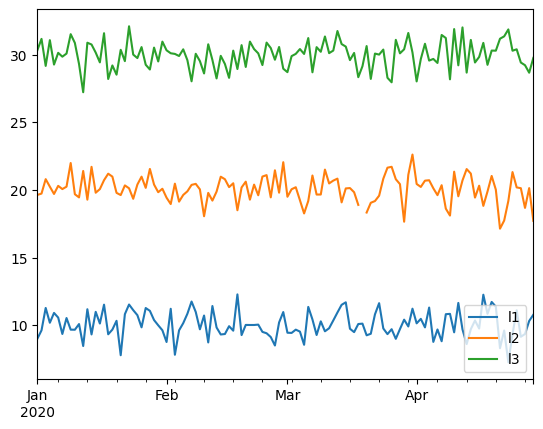

In [6]:
series.plot()

In [7]:
pd.concat(
    [
        series['l2'].loc[preds_2.query("level == 'l2'").index], 
        preds_1.query("level == 'l2'"), 
        preds_2.query("level == 'l2'")
    ], axis=1
)

,l2,level,fold,pred,level,fold,pred
2020-03-01,19.508446,l2,0,21.109596,l2,0,21.109596
2020-03-02,20.063756,l2,0,21.077912,l2,0,21.077912
2020-03-03,20.213189,l2,0,21.643152,l2,0,21.643152
2020-03-04,19.249204,l2,0,21.560616,l2,0,21.560616
2020-03-05,18.274620,l2,0,22.152952,l2,0,22.152952
2020-03-06,19.200396,l2,1,19.206286,l2,1,19.206286
2020-03-07,21.079606,l2,1,19.059529,l2,1,19.059529
2020-03-08,19.671333,l2,1,18.826102,l2,1,18.826102
2020-03-09,19.673293,l2,1,18.452918,l2,1,18.452918
2020-03-10,21.516802,l2,1,18.168881,l2,1,18.168881


In [8]:
preds_2.query("level == 'l2'")

,level,fold,pred
2020-03-01,l2,0,21.109596
2020-03-02,l2,0,21.077912
2020-03-03,l2,0,21.643152
2020-03-04,l2,0,21.560616
2020-03-05,l2,0,22.152952
2020-03-06,l2,1,19.206286
2020-03-07,l2,1,19.059529
2020-03-08,l2,1,18.826102
2020-03-09,l2,1,18.452918
2020-03-10,l2,1,18.168881


In [9]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

In [10]:
model = XGBRegressor(random_state=123, verbosity=0, tree_method='hist')
model = RandomForestRegressor(random_state=123)

X_train = series.values.reshape(-1, 1)
y_train = series['l1'].values  # Assuming 'l1' is the target variable

model.fit(series, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",123
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease 

In [11]:
series.isna().sum()

l1    0
l2    1
l3    0
dtype: int64

In [12]:
model.predict(series)

array([ 9.01555272,  9.63169729, 11.28789714, 10.18818572, 10.9231647 ,
       10.56268182,  9.36123015, 10.53573385,  9.68191421,  9.67942897,
       10.10195276,  8.50207213, 11.20335484,  9.32630093, 10.99182292,
       10.13915396, 11.52590724,  9.3420202 ,  9.68379011, 10.33559776,
        7.85154385, 10.83200758, 11.54449945, 11.11980006, 10.76327439,
        9.85344354, 11.29065952, 11.08576819, 10.38478336, 10.01452509,
        9.63458545,  8.77125818, 11.21999685,  7.93456769,  9.62836052,
       10.16461866, 10.85311846, 11.76760187, 10.99178711,  9.70693884,
       10.74406516,  8.74931346, 11.42804462,  9.84014097,  9.33090941,
        9.35969284,  9.93196327,  9.61343694, 12.22137235,  9.28261055,
       10.02758969, 10.0330379 , 10.0232178 , 10.04832153,  9.51125362,
        9.41844371,  9.13925908,  8.52396654, 10.19994593, 10.98783513,
        9.45434256,  9.4459911 ,  9.68189972,  9.53603463,  8.55601652,
       11.36832784, 10.42837153,  9.28624144, 10.31651774,  9.54

In [13]:
from skforecast.recursive import ForecasterRecursive
from skforecast.direct import ForecasterDirect, ForecasterDirectMultiVariate
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np

y = pd.Series(np.arange(100), index=pd.date_range(start='2020-01-01', periods=100, freq='D'))
forecaster = ForecasterRecursive(LinearRegression(), lags=5)
forecaster.fit(y)

last_window = y.iloc[-5:].copy()
last_window.iloc[2] = np.nan  # Introduce a NaN in the last window
forecaster.predict(steps=10, last_window=last_window)

╭──────────────────────────────── MissingValuesWarning ────────────────────────────────╮
│ `last_window` has missing values. Most of machine learning models do not allow       │
│ missing values. Prediction method may either raise an error or return NaN            │
│ predictions.                                                                         │
│                                                                                      │
│ Category : skforecast.exceptions.MissingValuesWarning                                │
│ Location :                                                                           │
│ /Users/javier.escobar/code/github/skforecast/skforecast/utils/utils.py:1393          │
│ Suppress : warnings.simplefilter('ignore', category=MissingValuesWarning)            │
╰──────────────────────────────────────────────────────────────────────────────────────╯

2020-04-10   NaN
2020-04-11   NaN
2020-04-12   NaN
2020-04-13   NaN
2020-04-14   NaN
2020-04-15   NaN
2020-04-16   NaN
2020-04-17   NaN
2020-04-18   NaN
2020-04-19   NaN
Freq: D, Name: pred, dtype: float64

In [14]:
y = pd.Series(np.arange(100), index=pd.date_range(start='2020-01-01', periods=100, freq='D'))
y.iloc[-2] = np.nan  # Introduce a NaN in the last window
forecaster = ForecasterRecursive(LinearRegression(), lags=5, dropna_from_series=True)
forecaster.fit(y)

forecaster.predict(steps=10)

╭──────────────────────────────── MissingValuesWarning ────────────────────────────────╮
│ NaNs detected in `y_train`. They have been dropped because the target variable       │
│ cannot have NaN values. Same rows have been dropped from `X_train` to maintain       │
│ alignment. This is caused by interspersed NaNs in `y`.                               │
│                                                                                      │
│ Category : skforecast.exceptions.MissingValuesWarning                                │
│ Location :                                                                           │
│ /Users/javier.escobar/code/github/skforecast/skforecast/recursive/_forecaster_recurs │
│ ive.py:979                                                                           │
│ Suppress : warnings.simplefilter('ignore', category=MissingValuesWarning)            │
╰──────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────── MissingValuesWarning ────────────────────────────────╮
│ NaNs detected in `X_train`. They have been dropped. If you want to keep them, set    │
│ `forecaster.dropna_from_series = False`. Same rows have been removed from `y_train`  │
│ to maintain alignment. This is caused by interspersed NaNs in `y` or `exog`.         │
│                                                                                      │
│ Category : skforecast.exceptions.MissingValuesWarning                                │
│ Location :                                                                           │
│ /Users/javier.escobar/code/github/skforecast/skforecast/recursive/_forecaster_recurs │
│ ive.py:994                                                                           │
│ Suppress : warnings.simplefilter('ignore', category=MissingValuesWarning)            │
╰──────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────── MissingValuesWarning ────────────────────────────────╮
│ `last_window` has missing values. Most of machine learning models do not allow       │
│ missing values. Prediction method may either raise an error or return NaN            │
│ predictions.                                                                         │
│                                                                                      │
│ Category : skforecast.exceptions.MissingValuesWarning                                │
│ Location :                                                                           │
│ /Users/javier.escobar/code/github/skforecast/skforecast/utils/utils.py:1393          │
│ Suppress : warnings.simplefilter('ignore', category=MissingValuesWarning)            │
╰──────────────────────────────────────────────────────────────────────────────────────╯

2020-04-10   NaN
2020-04-11   NaN
2020-04-12   NaN
2020-04-13   NaN
2020-04-14   NaN
2020-04-15   NaN
2020-04-16   NaN
2020-04-17   NaN
2020-04-18   NaN
2020-04-19   NaN
Freq: D, Name: pred, dtype: float64

In [15]:
y = pd.Series(np.arange(100), index=pd.date_range(start='2020-01-01', periods=100, freq='D'))
forecaster = ForecasterRecursive(
    LinearRegression(), lags=5, differentiation=1, dropna_from_series=True
)
forecaster.fit(y)

last_window = y.iloc[-6:].copy()
last_window.iloc[2] = np.nan  # Introduce a NaN in the last window
forecaster.predict(steps=5, last_window=last_window)

╭─────────────────────────────── IgnoredArgumentWarning ───────────────────────────────╮
│ The number of bins has been reduced from 10 to 1 due to duplicated edges caused by   │
│ repeated predicted values.                                                           │
│                                                                                      │
│ Category : skforecast.exceptions.IgnoredArgumentWarning                              │
│ Location :                                                                           │
│ /Users/javier.escobar/code/github/skforecast/skforecast/preprocessing/_preprocessing │
│ .py:2345                                                                             │
│ Suppress : warnings.simplefilter('ignore', category=IgnoredArgumentWarning)          │
╰──────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────── MissingValuesWarning ────────────────────────────────╮
│ `last_window` has missing values. Most of machine learning models do not allow       │
│ missing values. Prediction method may either raise an error or return NaN            │
│ predictions.                                                                         │
│                                                                                      │
│ Category : skforecast.exceptions.MissingValuesWarning                                │
│ Location :                                                                           │
│ /Users/javier.escobar/code/github/skforecast/skforecast/utils/utils.py:1393          │
│ Suppress : warnings.simplefilter('ignore', category=MissingValuesWarning)            │
╰──────────────────────────────────────────────────────────────────────────────────────╯

ValueError: Length of values (0) does not match length of index (5)

In [26]:
y = pd.Series(np.arange(100), index=pd.date_range(start='2020-01-01', periods=100, freq='D'))
forecaster = ForecasterDirect(
    LinearRegression(), lags=5, steps=5, differentiation=1, dropna_from_series=True
)
forecaster.fit(y)

last_window = y.iloc[-6:].copy()
last_window.iloc[2] = np.nan  # Introduce a NaN in the last window
forecaster.predict(steps=5, last_window=last_window)

╭─────────────────────────────── IgnoredArgumentWarning ───────────────────────────────╮
│ The number of bins has been reduced from 10 to 1 due to duplicated edges caused by   │
│ repeated predicted values.                                                           │
│                                                                                      │
│ Category : skforecast.exceptions.IgnoredArgumentWarning                              │
│ Location :                                                                           │
│ /Users/javier.escobar/code/github/skforecast/skforecast/preprocessing/_preprocessing │
│ .py:2340                                                                             │
│ Suppress : warnings.simplefilter('ignore', category=IgnoredArgumentWarning)          │
╰──────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────── MissingValuesWarning ────────────────────────────────╮
│ `last_window` has missing values. Most of machine learning models do not allow       │
│ missing values. Prediction method may either raise an error or return NaN            │
│ predictions.                                                                         │
│                                                                                      │
│ Category : skforecast.exceptions.MissingValuesWarning                                │
│ Location :                                                                           │
│ /Users/javier.escobar/code/github/skforecast/skforecast/utils/utils.py:1393          │
│ Suppress : warnings.simplefilter('ignore', category=MissingValuesWarning)            │
╰──────────────────────────────────────────────────────────────────────────────────────╯

2020-04-10   NaN
2020-04-11   NaN
2020-04-12   NaN
2020-04-13   NaN
2020-04-14   NaN
Freq: D, Name: pred, dtype: float64

In [12]:
series = pd.DataFrame(
    {f"l{i}": np.arange(100) + i for i in (1, 2, 3)},
    index=pd.date_range(start='2020-01-01', periods=100, freq='D')
)
forecaster = ForecasterDirectMultiVariate(LinearRegression(), lags=5, steps=5, level="l1")
forecaster.fit(series)

last_window = series.iloc[-5:].copy()
last_window.iloc[2] = np.nan  # Introduce a NaN in the last window
forecaster.predict(steps=5, last_window=last_window)

╭──────────────────────────────── MissingValuesWarning ────────────────────────────────╮
│ `last_window` has missing values. Most of machine learning models do not allow       │
│ missing values. Prediction method may fail.                                          │
│                                                                                      │
│ Category : skforecast.exceptions.MissingValuesWarning                                │
│ Location :                                                                           │
│ /Users/javier.escobar/code/github/skforecast/skforecast/utils/utils.py:1393          │
│ Suppress : warnings.simplefilter('ignore', category=MissingValuesWarning)            │
╰──────────────────────────────────────────────────────────────────────────────────────╯

,level,pred
2020-04-10,l1,NaN
2020-04-11,l1,NaN
2020-04-12,l1,NaN
2020-04-13,l1,NaN
2020-04-14,l1,NaN


╭────────────────────────────────────── h2o ───────────────────────────────────────╮
│ Description:                                                                     │
│ Monthly expenditure ($AUD) on corticosteroid drugs that the Australian health    │
│ system had between 1991 and 2008.                                                │
│                                                                                  │
│ Source:                                                                          │
│ Hyndman R (2023). fpp3: Data for Forecasting: Principles and Practice(3rd        │
│ Edition). http://pkg.robjhyndman.com/fpp3package/,https://github.com/robjhyndman │
│ /fpp3package, http://OTexts.com/fpp3.                                            │
│                                                                                  │
│ URL:                                                                             │
│ https://raw.githubusercontent.com/skforecast/skforecast-                         │
│ datasets/main/data/h2o.csv                                                       │
│                                                                                  │
│ Shape: 204 rows x 2 columns                                                      │
╰──────────────────────────────────────────────────────────────────────────────────╯

2005-07-01    0.973094
2005-08-01    1.022110
Freq: MS, Name: pred, dtype: float64

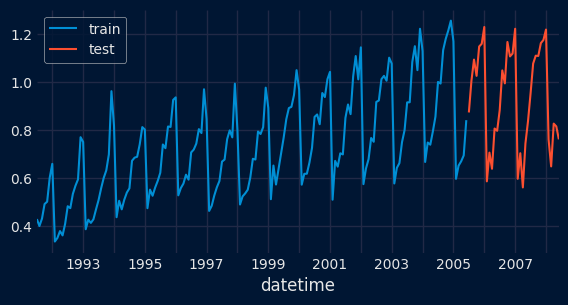

In [13]:
# Libraries
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error
from skforecast.datasets import fetch_dataset
from skforecast.preprocessing import RollingFeatures
from skforecast.recursive import ForecasterRecursive
from skforecast.plot import plot_prediction_intervals, set_dark_theme

# Download data
# ==============================================================================
data = fetch_dataset(
    name="h2o", raw=True, kwargs_read={"names": ["y", "datetime"], "header": 0}
)

# Data preprocessing
# ==============================================================================
data['datetime'] = pd.to_datetime(data['datetime'], format='%Y-%m-%d')
data = data.set_index('datetime')
data = data.asfreq('MS')
data = data['y']
data = data.sort_index()

# Split train-test
# ==============================================================================
steps = 36
data_train = data[:-steps]
data_test  = data[-steps:]

# Plot
# ==============================================================================
set_dark_theme()
fig, ax = plt.subplots(figsize=(6, 3))
data_train.plot(ax=ax, label='train')
data_test.plot(ax=ax, label='test')
ax.legend()

# Create and fit forecaster
# ==============================================================================
forecaster = ForecasterRecursive(
                 estimator       = Ridge(random_state=123),
                 lags            = 15,
                 window_features = RollingFeatures(stats=['mean'], window_sizes=10),
                 transformer_y   = None, 
             )

forecaster.fit(y=data_train, store_in_sample_residuals=True)
forecaster.predict(steps=steps).head(2)

In [14]:
# Create and fit forecaster
# ==============================================================================
data_train_nan = data_train.copy()
data_train_nan.iloc[-16:-10] = np.nan

forecaster = ForecasterRecursive(
                 estimator       = Ridge(),
                 lags            = 15,
                 window_features = RollingFeatures(stats=['mean'], window_sizes=10),
                 differentiation = 1 
             )

forecaster.fit(y=data_train_nan, store_in_sample_residuals=True)
print(forecaster.last_window_)
print(forecaster.last_window_.isna().sum())
_ = forecaster._create_predict_inputs(steps=5)
print(_[0])
print(np.isnan(_[0]).sum())
forecaster.predict(steps=5)

╭──────────────────────────────── MissingValuesWarning ────────────────────────────────╮
│ NaNs detected in `y_train`. They have been dropped because the target variable       │
│ cannot have NaN values. Same rows have been dropped from `X_train` to maintain       │
│ alignment. This is caused by interspersed NaNs in `y`.                               │
│                                                                                      │
│ Category : skforecast.exceptions.MissingValuesWarning                                │
│ Location :                                                                           │
│ /Users/javier.escobar/code/github/skforecast/skforecast/recursive/_forecaster_recurs │
│ ive.py:979                                                                           │
│ Suppress : warnings.simplefilter('ignore', category=MissingValuesWarning)            │
╰──────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────── MissingValuesWarning ────────────────────────────────╮
│ NaNs detected in `X_train`. Some estimators do not allow NaN values during training. │
│ If you want to drop them, set `forecaster.dropna_from_series = True`.                │
│                                                                                      │
│ Category : skforecast.exceptions.MissingValuesWarning                                │
│ Location :                                                                           │
│ /Users/javier.escobar/code/github/skforecast/skforecast/recursive/_forecaster_recurs │
│ ive.py:1003                                                                          │
│ Suppress : warnings.simplefilter('ignore', category=MissingValuesWarning)            │
╰──────────────────────────────────────────────────────────────────────────────────────╯

ValueError: Input X contains NaN.
Ridge does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values